In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis, pearsonr

In [2]:
df = pd.read_csv("../data/processed/financial_fraud_feature_engineered.csv")
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (1582354, 55)


,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,zip_count_4w,velocity_6h,velocity_24h,...,device_os_3,device_os_4,fraud_bool,address_stability,velocity_ratio,phone_verification_score,bank_relationship,customer_trust_score,transaction_velocity_score,digital_footprint
0,0.7,0.229712,34.0,63.0,50,0.024720,50.674001,1305,12764.326278,6418.672862,...,0,0,0,97.0,0.502821,1,48.0,22.282078,25181.526146,2.0
1,0.2,0.928428,199.0,24.0,70,0.014153,15.631407,833,9717.635327,6342.913428,...,0,0,0,223.0,0.652655,1,20.0,133.693656,20875.158423,2.0
2,0.1,0.658630,95.0,2.0,40,0.045801,-1.410133,237,2201.833206,2753.815567,...,0,0,0,97.0,1.250124,2,26.0,57.300798,8031.704263,3.0
3,0.8,0.774858,34.0,122.0,30,0.005569,-0.539938,895,5377.254660,4551.599208,...,0,0,0,156.0,0.846297,1,2.0,159.620824,14152.681371,2.0
4,0.9,0.993460,103.0,9.0,20,0.010832,-0.501067,4105,7428.775954,4872.930234,...,0,0,0,112.0,0.655865,2,2.0,113.254447,16552.466907,2.0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1582354 entries, 0 to 1582353
Data columns (total 55 columns):
 #   Column                            Non-Null Count    Dtype  
---  ------                            --------------    -----  
 0   income                            1582354 non-null  float64
 1   name_email_similarity             1582354 non-null  float64
 2   prev_address_months_count         1582354 non-null  float64
 3   current_address_months_count      1582354 non-null  float64
 4   customer_age                      1582354 non-null  int64  
 5   days_since_request                1582354 non-null  float64
 6   intended_balcon_amount            1582354 non-null  float64
 7   zip_count_4w                      1582354 non-null  int64  
 8   velocity_6h                       1582354 non-null  float64
 9   velocity_24h                      1582354 non-null  float64
 10  velocity_4w                       1582354 non-null  float64
 11  bank_branch_count_8w              1582354 non-nu

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
income,1582354.0,0.624148,0.265232,1.000000e-01,0.402251,0.700000,0.864429,0.900000
name_email_similarity,1582354.0,0.443923,0.271683,1.434550e-06,0.199744,0.415022,0.675152,0.999999
prev_address_months_count,1582354.0,39.679390,29.549773,5.000000e+00,34.000000,34.000000,34.000000,383.000000
current_address_months_count,1582354.0,99.442012,80.274059,0.000000e+00,39.589220,79.000000,141.277872,428.000000
customer_age,1582354.0,37.075410,11.964934,1.000000e+01,30.000000,39.000000,46.000000,90.000000
days_since_request,1582354.0,1.054368,5.078647,4.036860e-09,0.007740,0.014952,0.026840,78.456904
intended_balcon_amount,1582354.0,6.245535,17.352929,-1.553055e+01,-1.148283,-0.846093,-0.336909,112.956928
zip_count_4w,1582354.0,1595.919328,995.126585,1.000000e+00,908.000000,1286.000000,1984.000000,6700.000000
velocity_6h,1582354.0,5422.364438,2967.387088,-1.706031e+02,3173.848290,5092.157419,7408.849284,16715.565404
velocity_24h,1582354.0,4694.001588,1451.294353,1.320284e+03,3499.968803,4710.058458,5667.356189,9506.896596


In [5]:
#Mean, Median and Mode
summary = pd.DataFrame({"Mean": df.mean(numeric_only=True),"Median": df.median(numeric_only=True),
"Mode": df.mode().iloc[0]})
summary.head(15)

,Mean,Median,Mode
income,0.624148,0.700000,0.900000
name_email_similarity,0.443923,0.415022,0.006597
prev_address_months_count,39.679390,34.000000,34.000000
current_address_months_count,99.442012,79.000000,6.000000
customer_age,37.075410,39.000000,30.000000
days_since_request,1.054368,0.014952,0.004249
intended_balcon_amount,6.245535,-0.846093,-1.738736
zip_count_4w,1595.919328,1286.000000,926.000000
velocity_6h,5422.364438,5092.157419,588.145508
velocity_24h,4694.001588,4710.058458,3906.416302


In [6]:
# Variance and Standard Deviation
stats = pd.DataFrame({"Variance": df.var(numeric_only=True),"Std_Deviation": df.std(numeric_only=True)})
stats.head(15)

,Variance,Std_Deviation
income,7.034825e-02,0.265232
name_email_similarity,7.381148e-02,0.271683
prev_address_months_count,8.731891e+02,29.549773
current_address_months_count,6.443925e+03,80.274059
customer_age,1.431597e+02,11.964934
days_since_request,2.579265e+01,5.078647
intended_balcon_amount,3.011241e+02,17.352929
zip_count_4w,9.902769e+05,995.126585
velocity_6h,8.805386e+06,2967.387088
velocity_24h,2.106255e+06,1451.294353


In [7]:
# Skewness
skewness = df.select_dtypes(include=np.number).skew()
skewness.sort_values(ascending=False)

housing_status_6                     89.379540
payment_type_4                       82.746785
employment_status_6                  65.196994
housing_status_5                     33.928801
source_1                             16.433479
device_os_4                          16.332615
employment_status_4                   9.188042
days_since_request                    8.971036
housing_status_3                      8.458374
employment_status_3                   8.449466
foreign_request                       8.236999
employment_status_5                   6.474761
employment_status_2                   6.358126
prev_address_months_count             6.048711
device_os_1                           5.579934
payment_type_3                        3.449445
employment_status_1                   3.252174
bank_branch_count_8w                  3.157708
session_length_in_minutes             3.092162
intended_balcon_amount                3.037279
housing_status_4                      2.922039
has_other_car

In [8]:
# Kurtosis
kurt = df.select_dtypes(include=np.number).kurt()
kurt.sort_values(ascending=False)

velocity_ratio                      543613.823565
housing_status_6                      7986.712234
payment_type_4                        6845.039095
employment_status_6                   4248.653449
housing_status_5                      1149.164969
source_1                               268.059574
device_os_4                            264.754647
days_since_request                     101.634657
employment_status_4                     82.420223
housing_status_3                        69.544180
employment_status_3                     69.393563
foreign_request                         65.848231
prev_address_months_count               43.765833
employment_status_5                     39.922574
employment_status_2                     38.425815
device_os_1                             29.135699
session_length_in_minutes               12.733598
device_distinct_emails_8w               10.920474
intended_balcon_amount                  10.451167
payment_type_3                           9.898682


In [9]:
corr = df.corr(numeric_only=True)
corr

,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,zip_count_4w,velocity_6h,velocity_24h,...,device_os_3,device_os_4,fraud_bool,address_stability,velocity_ratio,phone_verification_score,bank_relationship,customer_trust_score,transaction_velocity_score,digital_footprint
income,1.000000,-0.068991,-0.001583,0.014526,0.161135,-0.009526,0.007071,-0.075770,-0.119726,-0.128404,...,0.055880,-0.007156,0.236301,0.013692,0.010451,-0.078985,-0.009847,0.100642,-0.149364,-0.127694
name_email_similarity,-0.068991,1.000000,0.001457,0.016501,-0.088286,-0.009929,0.061833,0.020567,0.041155,0.046658,...,0.025000,0.011499,-0.187678,0.016729,-0.002308,0.085346,0.003576,0.713723,0.054904,0.026080
prev_address_months_count,-0.001583,0.001457,1.000000,-0.133583,-0.038553,0.053897,0.005272,-0.007603,0.004495,0.004113,...,-0.011217,0.008925,-0.068435,0.230288,-0.000492,0.020791,-0.005205,-0.016421,0.005390,0.025721
current_address_months_count,0.014526,0.016501,-0.133583,1.000000,0.207098,-0.062039,0.025777,0.043312,0.018189,0.022742,...,0.062011,-0.009106,0.160755,0.933638,-0.002485,-0.060332,0.046498,0.111013,0.025086,-0.129498
customer_age,0.161135,-0.088286,-0.038553,0.207098,1.000000,-0.035395,-0.052757,-0.008862,-0.031996,-0.000122,...,0.123478,-0.004697,0.288822,0.189419,0.011677,-0.108098,0.014784,0.089350,-0.021398,-0.107897
days_since_request,-0.009526,-0.009929,0.053897,-0.062039,-0.035395,1.000000,0.022839,0.002917,0.034618,0.017155,...,-0.018402,0.007114,0.006074,-0.041436,-0.010715,-0.021181,0.002302,-0.055494,0.031493,0.011139
intended_balcon_amount,0.007071,0.061833,0.005272,0.025777,-0.052757,0.022839,1.000000,0.023389,0.066389,0.081405,...,-0.056875,0.030034,-0.142484,0.027217,-0.008819,0.088406,0.062915,0.009942,0.087910,0.023985
zip_count_4w,-0.075770,0.020567,-0.007603,0.043312,-0.008862,0.002917,0.023389,1.000000,0.133506,0.203897,...,-0.020230,0.001132,0.023892,0.039781,-0.007180,-0.030647,0.030565,-0.050998,0.220507,0.047515
velocity_6h,-0.119726,0.041155,0.004495,0.018189,-0.031996,0.034618,0.066389,0.133506,1.000000,0.474473,...,-0.034997,0.009141,-0.083274,0.019485,-0.171706,-0.001900,-0.003301,-0.082813,0.911118,0.063631
velocity_24h,-0.128404,0.046658,0.004113,0.022742,-0.000122,0.017155,0.081405,0.203897,0.474473,1.000000,...,-0.021863,0.007482,-0.053719,0.023817,0.013528,-0.047162,-0.011298,-0.069584,0.762116,0.053936


In [10]:
#Correlation with Fraud
fraud_corr = corr["fraud_bool"].sort_values(ascending=False)
fraud_corr

fraud_bool                          1.000000
credit_risk_score                   0.307430
customer_age                        0.288822
proposed_credit_limit               0.264019
income                              0.236301
current_address_months_count        0.160755
device_distinct_emails_8w           0.134376
address_stability                   0.133112
device_os_3                         0.104969
bank_months_count                   0.092389
customer_trust_score                0.049595
session_length_in_minutes           0.036054
zip_count_4w                        0.023892
velocity_ratio                      0.014488
days_since_request                  0.006074
month                              -0.002407
housing_status_6                   -0.011074
payment_type_4                     -0.011979
employment_status_6                -0.014922
housing_status_5                   -0.029190
velocity_24h                       -0.053719
velocity_4w                        -0.055409
source_1  

In [13]:
#Top Positive Correlation
fraud_corr.head(15)

fraud_bool                      1.000000
credit_risk_score               0.307430
customer_age                    0.288822
proposed_credit_limit           0.264019
income                          0.236301
current_address_months_count    0.160755
device_distinct_emails_8w       0.134376
address_stability               0.133112
device_os_3                     0.104969
bank_months_count               0.092389
customer_trust_score            0.049595
session_length_in_minutes       0.036054
zip_count_4w                    0.023892
velocity_ratio                  0.014488
days_since_request              0.006074
Name: fraud_bool, dtype: float64

In [14]:
#Top Negative Correlation
fraud_corr.tail(15)

payment_type_3                     -0.204925
phone_mobile_valid                 -0.210848
employment_status_1                -0.246105
payment_type_1                     -0.246503
date_of_birth_distinct_emails_4w   -0.270401
housing_status_4                   -0.293607
has_other_cards                    -0.336568
digital_footprint                  -0.336955
housing_status_1                   -0.338488
device_os_2                        -0.388747
housing_status_2                   -0.394097
phone_home_valid                   -0.407364
phone_verification_score           -0.466329
keep_alive_session                 -0.477422
device_fraud_count                       NaN
Name: fraud_bool, dtype: float64

In [15]:
cov_matrix = df.cov(numeric_only=True) #covariance matrix
cov_matrix.head()

,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,zip_count_4w,velocity_6h,velocity_24h,...,device_os_3,device_os_4,fraud_bool,address_stability,velocity_ratio,phone_verification_score,bank_relationship,customer_trust_score,transaction_velocity_score,digital_footprint
income,0.070348,-0.004971,-0.012404,0.309288,0.511361,-0.012832,0.032544,-19.998633,-94.229647,-49.426677,...,0.006845,-0.000115,0.031337,0.296884,0.011825,-0.011602,-0.030003,1.543860,-176.014044,-0.024379
name_email_similarity,-0.004971,0.073811,0.011697,0.359865,-0.286989,-0.013700,0.291509,5.560518,33.179008,18.396852,...,0.003137,0.000190,-0.025494,0.371562,-0.002675,0.012841,0.011162,11.214853,66.273161,0.005100
prev_address_months_count,-0.012404,0.011697,873.189107,-316.870404,-13.630829,8.088515,2.703230,-223.581068,394.182321,176.402719,...,-0.153094,0.016027,-1.011124,556.318703,-0.062048,0.340247,-1.767008,-28.064233,707.659518,0.547092
current_address_months_count,0.309288,0.359865,-316.870404,6443.924601,198.912163,-25.292232,35.907209,3459.909151,4332.620747,2649.431956,...,2.299077,-0.044422,6.452214,6127.054197,-0.850967,-2.682187,42.877472,515.408798,8947.190763,-7.482760
customer_age,0.511361,-0.286989,-13.630829,198.912163,143.159656,-2.150775,-10.953812,-105.521694,-1136.015277,-2.120331,...,0.682355,-0.003415,1.727871,185.281334,0.596056,-0.716298,2.032019,61.831308,-1137.538561,-0.929277


In [16]:
#Pearson Correlation Test
#Example using Credit Risk Score.
corr_value, p_value = pearsonr(df["credit_risk_score"],df["fraud_bool"])
print("Pearson Correlation :", corr_value)
print("P-value :", p_value)

Pearson Correlation : 0.30742978250232567
P-value : 0.0


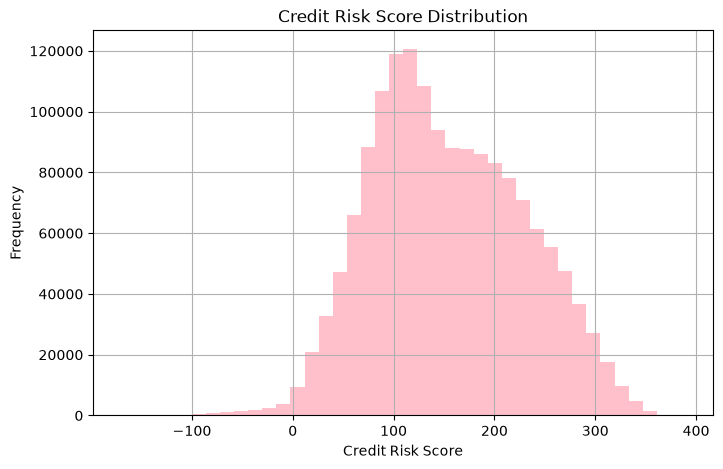

In [19]:
df["credit_risk_score"].hist(bins=40,figsize=(8,5),color="Pink")
plt.title("Credit Risk Score Distribution")
plt.xlabel("Credit Risk Score")
plt.ylabel("Frequency")
plt.show()

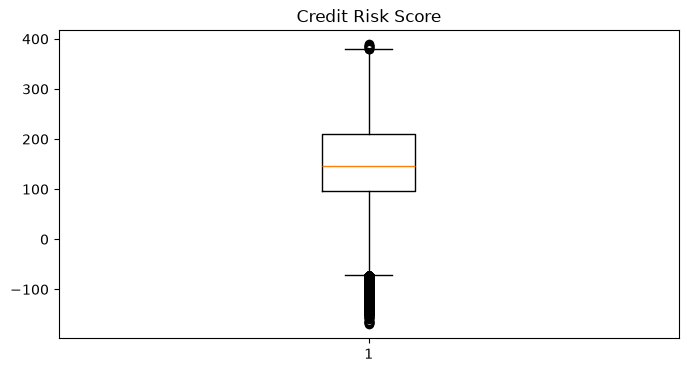

In [21]:
plt.figure(figsize=(8,4))
plt.boxplot(df["credit_risk_score"])
plt.title("Credit Risk Score")
plt.show()

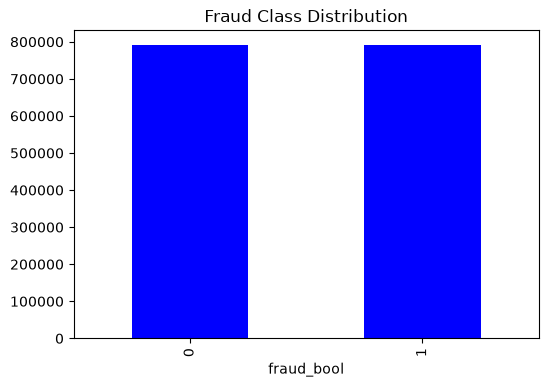

In [23]:
#Distribution of Fraud Class
df["fraud_bool"].value_counts().plot(color="Blue",kind="bar",figsize=(6,4))
plt.title("Fraud Class Distribution")
plt.show()

In [24]:
summary_stats = df.describe().T
summary_stats.to_csv("../data/processed/statistical_summary.csv")
print("Statistical summary saved.")

Statistical summary saved.


## Summary 

• Loaded the feature-engineered fraud detection dataset.
• Computed descriptive statistics (mean, median, mode, variance, and standard deviation).
• Evaluated skewness and kurtosis to understand feature distributions.
• Analyzed feature relationships using correlation and covariance matrices.
• Measured Pearson correlation between selected numerical features and the fraud target.

Pearson correlation analysis between credit_risk_score and fraud_bool produced a correlation coefficient of 0.3074 with a p-value < 0.001. This indicates a statistically significant weak-to-moderate positive relationship, suggesting that higher credit risk scores are associated with an increased likelihood of fraudulent transactions.

• Visualized feature distributions using histograms and boxplots.
• Examined the fraud class distribution.
• Saved the statistical summary for future reference.